# **Unsupervised Discovery of Conformational States in ROS1 Mutants from Molecular Dynamics Simulations**

## **Research Topic**
This project investigates conformational dynamics of the ROS1 kinase domain across multiple mutations associated with non-small-cell lung cancer (NSCLC). Molecular dynamics (MD) simulations generate high-dimensional structural data that are difficult to interpret directly.  

The objective of this study is to apply unsupervised learning methods to discover latent conformational states in these simulations and evaluate how different mutations redistribute the protein across these states.

## **Introduction**

The ROS1 receptor tyrosine kinase is an important oncogenic driver in a subset of non-small-cell lung cancers (NSCLC). Mutations within the kinase domain can alter structural dynamics and affect inhibitor binding or kinase activity. Molecular dynamics simulations provide a powerful way to explore these conformational changes at atomic resolution, but the resulting datasets are extremely high-dimensional.

Unsupervised learning provides a framework for discovering patterns in such data without predefined labels. Dimensionality reduction techniques such as Principal Component Analysis (PCA) allow complex molecular motions to be projected into a lower-dimensional space that captures the dominant structural variations. Clustering algorithms can then identify metastable conformational states sampled during the simulations.

In this project, unsupervised learning is applied to MD trajectories of ROS1 mutants. Two complementary feature representations are explored:

1. **Core structural coordinates excluding the activation loop (ACT-OUT)**  
2. **Relative orientation between the N-terminal and C-terminal kinase lobes**

By comparing clustering results across these representations, we aim to determine which structural features best capture mutation-dependent conformational differences.

### **Outline**
 - Data + preprocessing (alignment, subsampling)
 - Feature Set 1: Core coords excluding A-loop → PCA → HDBSCAN (primary) + DBSCAN (baseline) → occupancy per mutant
 - Feature Set 2: NTL–CTL orientation → PCA → HDBSCAN (primary) + DBSCAN (baseline) → occupancy per mutant
 - Results summary (what states we found and which mutations shift occupancy)

In [1]:
# importing necessary libraries
import os
import numpy as np
import MDAnalysis as mda
import molly
from MDAnalysis.analysis.dssp import DSSP
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import hdbscan
import pandas as pd

from scripts.clustering import run_hdbscan, run_dbscan
from scripts.occupancy import occupancy_from_traj_labels
from scripts.plotting import (
    plot_occupancy_heatmap,
    plot_cluster_population,
    plot_pca_clusters
)

import timer
tim = timer.Timer()

eps = 1e-6

/homes/lkgyammerah/.venvs/ros1_analysis_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Data Preparation and Preprocessing**

The molecular dynamics trajectories used in this study were generated using the **GROMACS molecular dynamics package**. Each simulation represents a ROS1 kinase mutant associated with non-small-cell lung cancer (NSCLC). Multiple simulations were performed for each mutant to capture conformational variability.

Before applying machine learning methods, several preprocessing steps were required:

1. **Trajectory loading**
   All trajectories were loaded and parsed using Python tools compatible with molecular dynamics data.

2. **Atom selection**
   A consistent atom selection was constructed across all trajectories to ensure that the same atoms were used for analysis. This is necessary for meaningful comparison of structural coordinates.

3. **Structural alignment**
   Each trajectory frame was aligned to a common reference structure. This removes global translation and rotation and ensures that only internal structural changes are analyzed.

4. **Subsampling**
   Frames were subsampled to obtain a consistent number of frames across trajectories while reducing computational cost.

5. **Domain masking**
   Specific structural regions of the kinase domain were defined, including:
   - N-terminal lobe (NTL)
   - C-terminal lobe (CTL)
   - Activation loop

These preprocessing steps transform raw MD trajectories into a structured dataset suitable for unsupervised learning.

In [2]:
# ============================================
# 1) ONE authoritative selection 
# ============================================
selection = "protein and name N CA C O CB CG and not element H"

In [3]:
# ============================================
# 2) Auto-detect mutants + build simulation list F 
# ============================================

IGNORE = {
    "__pycache__",
    "orientation_cluster_reps",   
    "figures",
    "plots",
    "tmp",
}

mutants = []
for d in sorted(os.listdir(".")):
    if not os.path.isdir(d): 
        continue
    if d in IGNORE:
        continue
    if os.path.exists(f"{d}/Simulation_1/md-prot.pdb"):
        mutants.append(d)

print("Detected mutants:", mutants)
nrep = 3
F = [f"{mut}/Simulation_{run}" for mut in mutants for run in (1, 2, 3)]
print("Total simulations:", len(F))

Detected mutants: ['C2060G', 'D1988N', 'D2033N', 'D2113G', 'D2113N', 'E1935G', 'E1990G', 'E2020K', 'E2131Q', 'F1994L', 'F2004C', 'F2004L', 'F2004V', 'F2075V', 'G1957A', 'G1971E', 'G2032K', 'G2032R', 'G2048A_NC', 'G2101A', 'H1999Q_NC', 'L1947R', 'L1951R', 'L1982F', 'L1982V', 'L2010M', 'L2026M', 'L2053V_NC', 'L2086F', 'L2155S', 'Q2022P', 'Q2022P_S1986F', 'Q2022P_S1986Y', 'R2078K', 'S1986F', 'S1986Y', 'V2089M', 'V2098I', 'WT']
Total simulations: 117


In [4]:
# =========================
# locking trajectory paths so F never gets overwritten
# =========================

# Save the real paths exactly once
if "F_paths" not in globals():
    assert "F" in globals(), "Define F (list of traj folder strings) first."
    assert isinstance(F, list) and isinstance(F[0], str), "F must be list[str] when you save it."
    F_paths = F.copy()

# Always use F_paths as truth
F = F_paths.copy()

print("[OK] F restored:", type(F), "len(F)=", len(F), "example:", F[0])

[OK] F restored: <class 'list'> len(F)= 117 example: C2060G/Simulation_1


In [5]:
# selecting the number of frames based on the minimum across trajectories


stride = 1  

def subsampled_len(d, stride=stride):
    u = mda.Universe(f"{d}/md-prot.pdb", f"{d}/md-prot.xtc")
    return len(np.arange(len(u.trajectory))[::stride])

nframes_sub = min(subsampled_len(d) for d in F)
print("[frame_idx_list] Using nframes_sub =", nframes_sub)

def get_frame_idx(d, stride=stride, nsub=nframes_sub):
    u = mda.Universe(f"{d}/md-prot.pdb", f"{d}/md-prot.xtc")
    idx = np.arange(len(u.trajectory))[::stride]
    return idx[:nsub]

frame_idx_list = [get_frame_idx(d) for d in F]

print("[frame_idx_list] built for", len(frame_idx_list), "trajectories.")
print("[frame_idx_list] example first/last:", frame_idx_list[0][0], frame_idx_list[0][-1])

[frame_idx_list] Using nframes_sub = 696
[frame_idx_list] built for 117 trajectories.
[frame_idx_list] example first/last: 0 695


In [6]:
# ============================================
# 3) Helper: reading XTC for a GIVEN atom index list (per sim)
# ============================================
def xtc2array_varlen_by_indices(d, atom_indices, frame_selection=None):
    """
    Reads ONLY atom_indices (0-based indices into Universe atoms)
    Returns xyz: (T, nsel, 3), pbc: (T, 3, 3)
    """
    m = molly.XTCReader(f"{d}/md-prot.xtc")
    nframes = len(m.read_frames(atom_selection=[], frame_selection=frame_selection))
    m.home()

    out = np.zeros((nframes, len(atom_indices), 3), dtype=np.float32)
    pbc = np.empty((nframes, 3, 3), dtype=np.float32)

    m.read_into_array(out, pbc, atom_selection=[int(i) for i in atom_indices], frame_selection=frame_selection)

    # keep your pbc convention
    pbc = np.array(pbc).transpose((0, 2, 1))  # (T,3,3)
    return out, pbc

In [7]:
# ============================================
# 3b) COMMON ATOMS intersection 
#     Building keys by (resid, atomname) within the selection
# ============================================
def selection_keys_and_indices(d, selection):
    """
    Returns:
      keys: set of (resid, name) for atoms in selection
      key_to_index: dict mapping key -> atom_index (0-based)
    """
    u = mda.Universe(f"{d}/md-prot.pdb")
    ag = u.select_atoms(selection)

    # key: (resid, atomname)
    # Use resid from the topology (1..291). Later we apply +1933 only for plotting.
    keys = []
    key_to_index = {}
    for a in ag:
        k = (int(a.resid), str(a.name))
        keys.append(k)
        key_to_index[k] = int(a.ix)  # 0-based atom index in Universe
    return set(keys), key_to_index

with tim("Computing COMMON selection atoms across all simulations"):
    all_keysets = []
    all_maps = []

    for d in F:
        keys, k2i = selection_keys_and_indices(d, selection)
        all_keysets.append(keys)
        all_maps.append(k2i)

    common_keys = set.intersection(*all_keysets)
    print("Selection sizes (min/max):", min(len(s) for s in all_keysets), max(len(s) for s in all_keysets))
    print("COMMON atoms kept:", len(common_keys))

    if len(common_keys) == 0:
        raise ValueError("COMMON atom set is empty — selection too strict or inconsistent topologies.")

    # keep a stable order: by resid then atomname
    common_keys_sorted = sorted(list(common_keys), key=lambda x: (x[0], x[1]))

    # per sim: the atom indices to read from xtc (same order for all sims)
    per_sim_indices = []
    for k2i in all_maps:
        idx = [k2i[k] for k in common_keys_sorted]
        per_sim_indices.append(idx)

# Building authoritative meta from the FIRST sim, using the COMMON indices in the SAME order
u0 = mda.Universe(f"{F[0]}/md-prot.pdb")
meta = u0.atoms[per_sim_indices[0]]
natoms = len(meta)
print("Authoritative natoms (common):", natoms)

Selection sizes (min/max): 1627 1630
COMMON atoms kept: 1626
[TIMER] Computing COMMON selection atoms across all simulations: 5.692 s
Authoritative natoms (common): 1626


In [8]:
# ============================================
# 3c) Read all trajectories (variable length, COMMON atoms only)
# ============================================
with tim("Reading all trajectories (true variable length, common atoms only)"):
    traj_xyz = []
    traj_pbc = []
    for d, idx in zip(F, per_sim_indices):
        fi = frame_idx_list[F.index(d)].tolist() 
        xyz, pbc = xtc2array_varlen_by_indices(d, idx, frame_selection=fi)
        traj_xyz.append(xyz)
        traj_pbc.append(pbc)

traj_len = [x.shape[0] for x in traj_xyz]
print("Frames min/max:", min(traj_len), max(traj_len))


[TIMER] Reading all trajectories (true variable length, common atoms only): 18.734 s
Frames min/max: 696 696


In [9]:
# ============================================
# 4) Masks (computed on COMMON meta)
# ============================================
CA  = (meta.names == "CA")
BB  = np.isin(meta.names, ["N", "CA", "C", "O"])
resids_atom = meta.resids + 1933

# BODY: same as your style (but now based on meta.resids)
BODY = np.isin(meta.resids, np.arange(6, 278))

mode = "BB"
if mode == "CA":
    sele = CA
    fit  = CA & BODY
elif mode == "BB":
    sele = BB
    fit  = BB & BODY
else:
    raise ValueError("mode must be 'CA' or 'BB'")

print("mode:", mode, "sele atoms:", int(sele.sum()), "fit atoms:", int(fit.sum()))


mode: BB sele atoms: 1167 fit atoms: 1088


In [10]:
# ============================================
# 5) DSSP background (WT reference)
# ============================================
r = mda.Universe('WT/Simulation_1/md-prot.pdb', 'WT/Simulation_1/md-prot.pdb').select_atoms('resid 1-291')
with tim("Secondary structure (DSSP)"):
    secondary_structure = ''.join(DSSP(r).run().results.dssp[0]) + '-'
print(secondary_structure)

resids_ca = resids_atom[CA]


[TIMER] Secondary structure (DSSP): 0.110 s
--------HHHEEE-EE-E----EEEEEEEEE--------EEEEEEEEE-----HHHHHHHHHHHHHHH------E--E-EEE------EEEEE-----EHHHHHH----EE--EE---HHHH-HHHHHHHHHHHHHH---EE---------EE----------EEE------EE------EE-------------HHHHH--EE-HHHHHHHHHHHHHHHH-----------HHHHHHH--------------HHHHHHHHHH----------HHHHHHHHHHHH------


/homes/lkgyammerah/.venvs/ros1_analysis_env/lib/python3.13/site-packages/MDAnalysis/analysis/base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


In [11]:
# ============================================
# 6) Plot reference axes cube (E) 
# ============================================
E = np.array((
    0,0,0, 1,0,0,
    0,0,0, 0,1,0,
    0,0,0, 0,0,1,
    1,0,0, 1,1,0,
    1,0,0, 1,0,1,
    0,1,0, 1,1,0,
    0,1,0, 0,1,1,
    0,0,1, 1,0,1,
    0,0,1, 0,1,1,
    1,1,0, 1,1,1,
    1,0,1, 1,1,1,
    0,1,1, 1,1,1,
)).reshape((12, 2, 3)) @ traj_pbc[0][0]
print("E shape:", E.shape)

E shape: (12, 2, 3)


Reference simulation: WT/Simulation_1


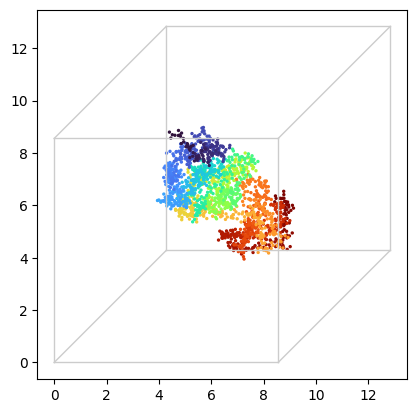

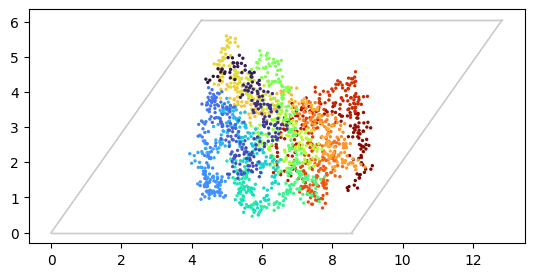

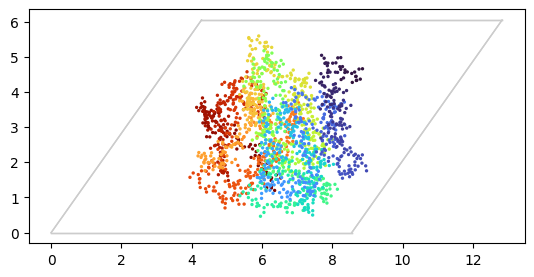

In [12]:
# ============================================
# 7) Reference choice 
# ============================================
ref_sim_index = -3
print("Reference simulation:", F[ref_sim_index])

ref = traj_xyz[ref_sim_index][0].copy()  # (natoms,3) on COMMON atoms

for k in ([0,1], [0,2], [1,2]):
    plt.scatter(*ref[:, k].T, c=-np.arange(len(ref)), cmap='turbo', s=2)
    for e in E:
        plt.plot(*e[:, k].T, c='#ccc', linewidth=1)
    plt.gca().set_aspect('equal')
    plt.show()

In [13]:
# ============================================
# 8) Reference views + alignment (FIXED)
# ============================================

ref_centered = ref - ref[fit].mean(axis=0, keepdims=True)
ref_fit = ref_centered[fit]
ref_fit = ref_fit - ref_fit.mean(axis=0, keepdims=True)  # (nfit,3)

def align_traj_to_ref(xyz, fit_mask, ref_fit_centered):
    """
    xyz: (T, natoms, 3) on COMMON atoms
    """
    xyz = xyz.copy().astype(np.float64)

    xyz -= xyz[:, fit_mask].mean(axis=1, keepdims=True)
    Xfit = xyz[:, fit_mask]  # (T, nfit, 3)

    M = np.einsum('ij,tjk->tik', (ref_fit_centered.T / (3 * ref_fit_centered.shape[0])), Xfit)  # (T,3,3)
    U, S, Vt = np.linalg.svd(M)
    R = U @ Vt  # (T,3,3)

    xyz = xyz @ np.transpose(R, (0, 2, 1))
    return xyz.astype(np.float32)

with tim("Aligning ALL trajectories to ONE reference (variable length)"):
    traj_aligned = []
    for xyz in traj_xyz:
        traj_aligned.append(align_traj_to_ref(xyz, fit, ref_fit))


[TIMER] Aligning ALL trajectories to ONE reference (variable length): 12.859 s


[TIMER] RMSD per trajectory (vs own first frame): 4.287 s


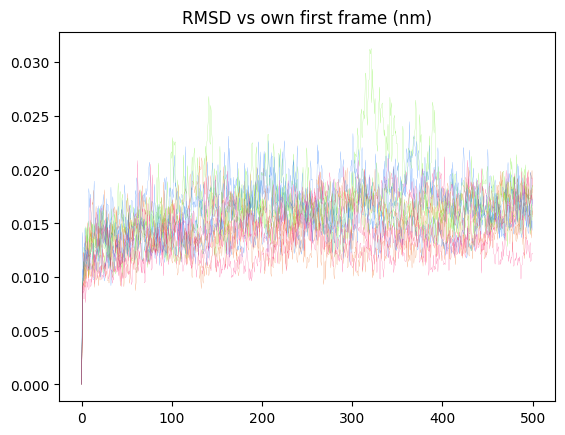

In [14]:
# ============================================
# 9) RMSD vs own first frame (per trajectory)
# ============================================
colors = ('#ee5500', '#55ee00', '#0066ff', '#ff0066')

with tim("RMSD per trajectory (vs own first frame)"):
    rmsd_list = []
    for xyz in traj_aligned:
        x0 = xyz[0, sele]
        dif = xyz[:, sele] - x0[None, :, :]
        r = np.sqrt((dif * dif).sum(axis=(1,2)) / sele.sum()) / 10.0
        rmsd_list.append(r)

for r, c in zip(rmsd_list, np.repeat(colors, 3)):
    t = np.linspace(0, 500, num=len(r))
    plt.plot(t, r, c=c, linewidth=0.1)
plt.title("RMSD vs own first frame (nm)")
plt.show()

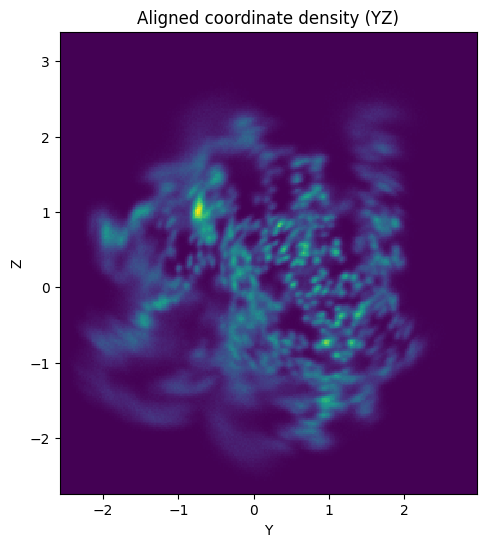

In [15]:
# ============================================
# 10) Plot of all structures aligned (YZ density)
# ============================================
stride_density = 10
YZ_all = []
for xyz in traj_aligned:
    A = xyz[::stride_density, sele, 1:].reshape((-1, 2))
    mask = ~((np.abs(A[:,0]) < 1e-6) & (np.abs(A[:,1]) < 1e-6))
    YZ_all.append(A[mask])
YZ_all = np.vstack(YZ_all)

plt.figure(figsize=(7,6))
plt.hist2d(YZ_all[:,0], YZ_all[:,1], bins=256)
plt.gca().set_aspect('equal')
plt.title("Aligned coordinate density (YZ)")
plt.xlabel("Y")
plt.ylabel("Z")
plt.show()

In [16]:
# ============================================
# 11) RMSF (per traj + overall)
# ============================================
with tim("RMSF per trajectory (variable length)"):
    rmsf_list = []
    for xyz in traj_aligned:
        mean_i = xyz.mean(axis=0, keepdims=True)
        rmsf_i = np.sqrt(((xyz - mean_i)**2).sum(axis=(0,2)) / xyz.shape[0])  # (natoms,)
        rmsf_list.append(rmsf_i)
    rmsf = np.vstack(rmsf_list)
    overall = rmsf.mean(axis=0)

# ============================================
# 11.5) Domain masks
# ============================================
NTL = (resids_atom >= 1934) & (resids_atom <= 2030)
CTL = (resids_atom >= 2031) & (resids_atom <= 2225)
CHX = (resids_atom >= 1960) & (resids_atom <= 1975)
PLP = (resids_atom >= 1980) & (resids_atom <= 1990)

[TIMER] RMSF per trajectory (variable length): 2.783 s


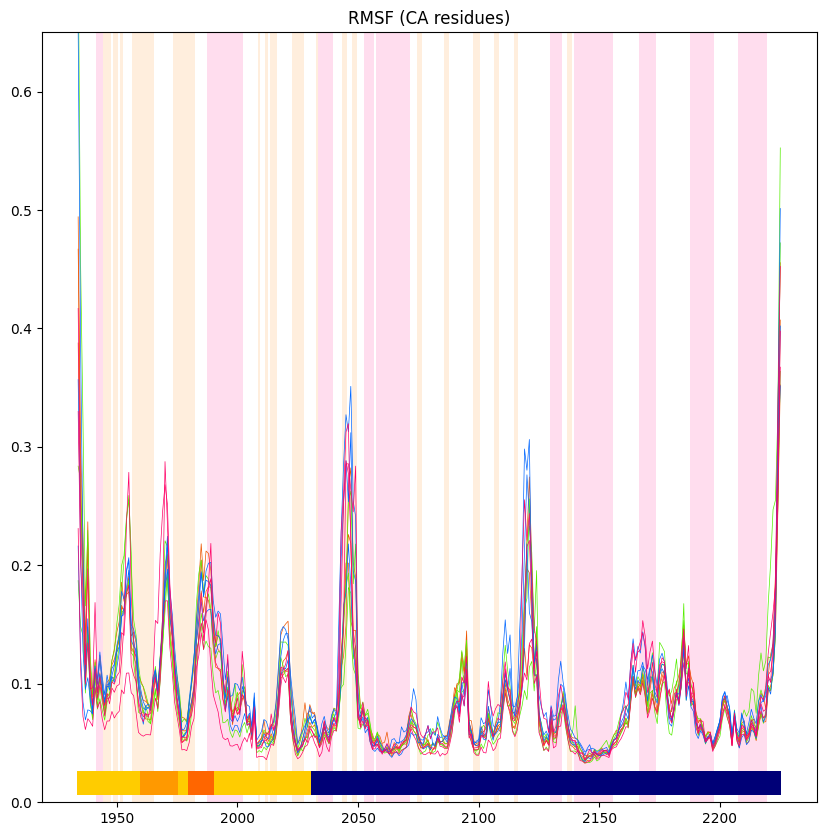

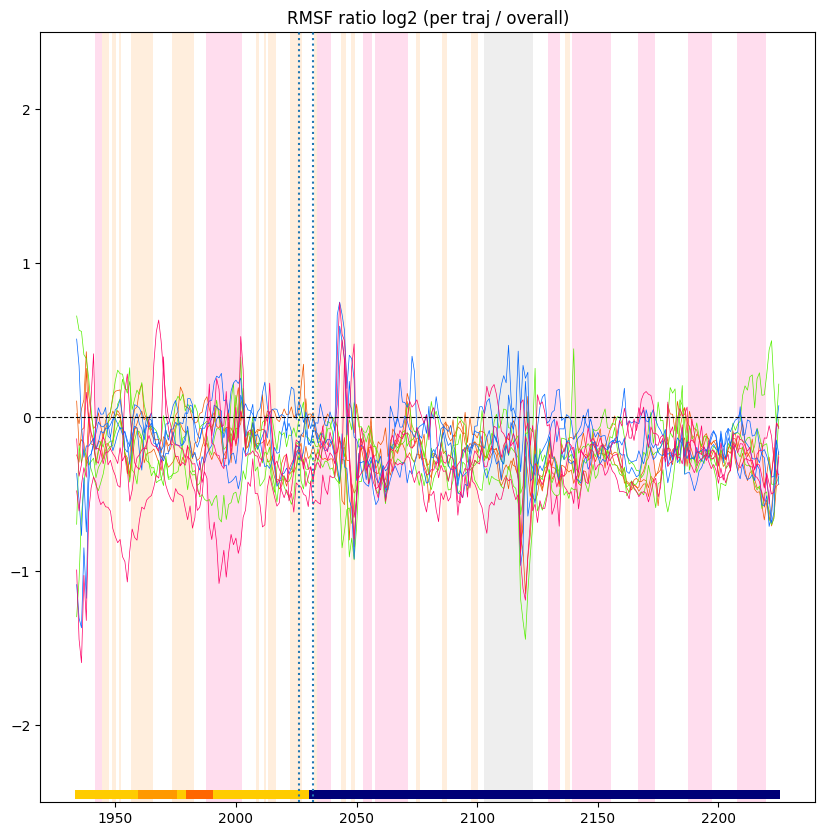

In [17]:
# ============================================
# 12) RMSF plot (CA) + domain band
# ============================================
fig, ax = plt.subplots(figsize=(10, 10))

for s, c in zip(rmsf, np.repeat(colors, 3)):
    ax.plot(resids_atom[CA], s[CA], c=c, linewidth=0.5)

for x, ss in zip(resids_ca, secondary_structure):
    if ss == 'H':
        fc = '#ffddee'
    elif ss == 'E':
        fc = '#ffeedd'
    else:
        fc = 'white'
    ax.add_patch(patches.Rectangle((x - 0.5, 0), 1, 1, facecolor=fc, zorder=0))

ax.set_ylim((0, 0.65))

ymin, ymax = ax.get_ylim()
bar_h = 0.03 * (ymax - ymin)
bar_y = ymin + 0.01 * (ymax - ymin)

for dom_mask, col in ((NTL, '#ffcc00'), (CTL, '#000077'), (CHX, '#ff9900'), (PLP, '#ff6600')):
    dom_ca = np.where(dom_mask & CA)[0]
    if len(dom_ca) == 0:
        continue
    x0 = resids_atom[dom_ca[0]]
    x1 = resids_atom[dom_ca[-1]]
    ax.add_patch(
    patches.Rectangle(
        (x0 - 0.5, bar_y),
        (x1 - x0) + 1,
        bar_h,
        facecolor=col,
        zorder=10
    )
)

plt.title("RMSF (CA residues)")
plt.show()

fig, ax = plt.subplots(figsize=(10, 10))

ratio = rmsf / (overall + 1e-12)   # keep simple broadcasting

ymin, ymax = -2.5, 2.5
ax.set_ylim((ymin, ymax))

for x, ss in zip(resids_ca, secondary_structure):
    fc = '#fde' if ss == 'H' else ('#fed' if ss == 'E' else 'white')
    ax.add_patch(patches.Rectangle((x - 0.5, ymin), 1, ymax - ymin, facecolor=fc, zorder=0))

ax.add_patch(patches.Rectangle((2103, ymin), 20, ymax - ymin, facecolor='#eee', zorder=1))

bar_h = 0.06
bar_y = ymin + 0.02
for dom_mask, col in (NTL, '#ffcc00'), (CTL, '#000077'), (CHX, '#ff9900'), (PLP, '#ff6600'):
    dom_ca = np.where(dom_mask & CA)[0]
    if len(dom_ca) == 0:
        continue
    x0 = resids_atom[dom_ca[0]]
    x1 = resids_atom[dom_ca[-1]]
    ax.add_patch(patches.Rectangle((x0 - 0.5, bar_y), (x1 - x0) + 1, bar_h, facecolor=col, zorder=2))

for s, c in zip(ratio, np.repeat(colors, 3)):
    ax.plot(resids_atom[CA], np.log2(s[CA] + 1e-12), c=c, linewidth=0.5, zorder=5)

ax.axvline(2026, linestyle=':', zorder=6)
ax.axvline(2032, linestyle=':', zorder=6)
ax.axhline(0, color='k', linestyle='--', linewidth=0.8, zorder=6)

plt.title("RMSF ratio log2 (per traj / overall)")
plt.show()




## **Methods**

### **Data**
The dataset consists of molecular dynamics trajectories of ROS1 kinase mutants. Each trajectory contains multiple frames representing protein conformations sampled over time.

### **Preprocessing**
All trajectories were aligned to a common reference structure to remove rigid-body translation and rotation. A consistent atom selection across all simulations was constructed to ensure comparability between trajectories.

### **Feature Sets**

Two feature representations were constructed:

**Feature Set 1 – ACT-OUT core coordinates**  
Backbone coordinates of the kinase domain excluding the activation loop were used. Removing the activation loop reduces the dominance of highly flexible regions and emphasizes the global kinase scaffold.

**Feature Set 2 – Orientation features**  
Relative geometric descriptors between the N-terminal and C-terminal kinase lobes were computed. These include vectors and principal axes describing the orientation of each lobe.

### **Dimensionality Reduction**
Principal Component Analysis (PCA) was applied to each feature set. PCA projects the high-dimensional data onto orthogonal components capturing the largest variance in the system.

### **Clustering**
Density-based clustering algorithms were used to identify conformational states:

- **HDBSCAN** (primary method)  
- **DBSCAN** (baseline comparison)

These algorithms identify clusters of high density in the reduced PCA space while allowing noise or outlier conformations.

### **Occupancy Analysis**
Cluster assignments were mapped back to the original trajectories to compute **state occupancies per mutant**, allowing comparison of conformational preferences across different ROS1 mutations.

# **ACT-OUT feature construction + PCA**

This section constructs the first feature representation used in the analysis: **core backbone coordinates excluding the activation loop (ACT-OUT)**.

The activation loop is a highly flexible region in kinase structures. Including it can dominate the variance in molecular dynamics trajectories and obscure more subtle structural variations in the kinase core. To focus on the global scaffold of the protein, backbone coordinates within the activation loop are excluded from this representation.

After aligning trajectories to the ACT-OUT reference structure, the selected backbone coordinates are vectorized and centered to compute structural deviations. Principal Component Analysis (PCA) is then applied to this representation to identify the dominant modes of structural variation in the kinase core.

The resulting PCA scores provide a reduced-dimensional description of the conformational ensemble, which is subsequently used for density-based clustering.

The scatter plot below shows the projection of ACT-OUT conformations onto the first two principal components, illustrating the dominant structural variation in the kinase core.

ACT-OUT sele atoms: 984
ACT-OUT fit atoms : 984
[TIMER] B1: ACT-OUT aligning all trajectories on ACT-OUT fit: 12.115 s
[TIMER] B1: ACT-OUT vectorize deviations + build X_actout and owners: 6.481 s
X_actout shape: (16380, 2952)
X_owner_actout shape: (16380,)
[TIMER] B1: ACT-OUT PCA diagonalization: 23.949 s


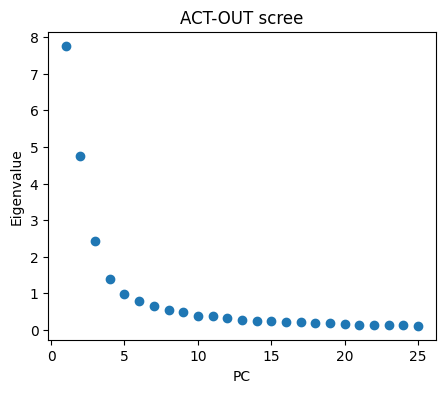

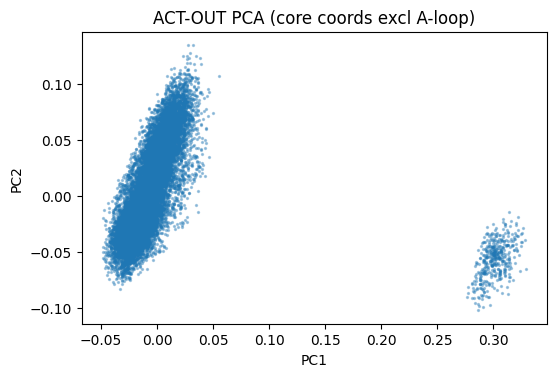

In [18]:
# ============================================================
# FEATURE SET 1: CORE COORDS EXCLUDING ACTIVATION LOOP (ACT-OUT)
# ============================================================


# --- ACT loop in meta.resids space (your notebook uses 1933 offset) ---
act_lo = 2045 - 1933   # 112
act_hi = 2070 - 1933   # 137
ACT = (meta.resids >= act_lo) & (meta.resids <= act_hi)

# backbone/body excluding ACT
sele_actout = BB & BODY & (~ACT)
fit_actout  = sele_actout

print("ACT-OUT sele atoms:", int(sele_actout.sum()))
print("ACT-OUT fit atoms :", int(fit_actout.sum()))

ref_actout_centered = ref_centered.copy()
ref_fit_actout = ref_actout_centered[fit_actout]
ref_fit_actout = ref_fit_actout - ref_fit_actout.mean(axis=0, keepdims=True)

def align_traj_to_ref_by_fit(xyz, fit_mask, ref_fit_centered):
    xyz = xyz.copy().astype(np.float64)
    xyz -= xyz[:, fit_mask].mean(axis=1, keepdims=True)
    Xfit = xyz[:, fit_mask]
    M = np.einsum('ij,tjk->tik', (ref_fit_centered.T / (3 * ref_fit_centered.shape[0])), Xfit)
    U, S, Vt = np.linalg.svd(M)
    R = U @ Vt
    xyz = xyz @ np.transpose(R, (0, 2, 1))
    return xyz.astype(np.float32)

with tim("B1: ACT-OUT aligning all trajectories on ACT-OUT fit"):
    traj_actout = [align_traj_to_ref_by_fit(xyz, fit_actout, ref_fit_actout) for xyz in traj_aligned]

# vectorize selection coords, build mean, then build X (last 20% frames)
with tim("B1: ACT-OUT vectorize deviations + build X_actout and owners"):
    all_frames = []
    for xyz in traj_actout:
        all_frames.append(xyz[:, sele_actout].reshape(xyz.shape[0], -1))
    all_frames = np.vstack(all_frames)

    mean_actout = all_frames.mean(axis=0)
    d_actout = mean_actout.size

    X_list, X_owner_list = [], []
    for ti, xyz in enumerate(traj_actout):
        dev = xyz[:, sele_actout].reshape(xyz.shape[0], -1) - mean_actout
        split_idx = int(0.8 * dev.shape[0])
        X_i = dev[split_idx:]
        if X_i.shape[0] > 0:
            X_list.append(X_i)
            X_owner_list.append(np.full(X_i.shape[0], ti, dtype=int))

    X_actout = np.vstack(X_list) if len(X_list) else np.zeros((0, d_actout))
    X_owner_actout = np.concatenate(X_owner_list) if len(X_owner_list) else np.zeros((0,), dtype=int)

print("X_actout shape:", X_actout.shape)
print("X_owner_actout shape:", X_owner_actout.shape)

# PCA
with tim("B1: ACT-OUT PCA diagonalization"):
    C = (X_actout.T @ X_actout) / len(X_actout)
    evals_actout, loadings_actout = np.linalg.eigh(C)
    order = np.argsort(evals_actout)[::-1]
    evals_actout = evals_actout[order]
    loadings_actout = loadings_actout[:, order]

plt.figure(figsize=(5,4))
plt.scatter(np.arange(1, 26), evals_actout[:25])
plt.xlabel("PC")
plt.ylabel("Eigenvalue")
plt.title("ACT-OUT scree")
plt.show()

ncomponents_actout = 10
scale_actout = np.sqrt(mean_actout.size)
scores_flat_actout = (X_actout @ loadings_actout[:, :ncomponents_actout]) / scale_actout

plt.figure(figsize=(6,5))
plt.scatter(scores_flat_actout[:,0], scores_flat_actout[:,1], s=2, alpha=0.35)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("ACT-OUT PCA (core coords excl A-loop)")
plt.show()

# **ACT-OUT CLUSTERING + OCCUPANCY PER MUTANT**

The ACT-OUT PCA representation was clustered using two density-based methods: **HDBSCAN** as the primary method and **DBSCAN** as a baseline comparison.

After clustering, the cluster labels were mapped back to the original trajectory frames in order to compute **state occupancies per mutant**. State occupancy is defined as the fraction of frames from a given mutant assigned to each conformational cluster. This provides a quantitative view of how strongly each mutant populates the identified ACT-OUT states.

In [19]:
# ============================================================
# ACT-OUT CLUSTERING + OCCUPANCY PER MUTANT
# Primary: HDBSCAN
# Baseline: DBSCAN
# ============================================================

# Use the first 5 principal components for clustering in ACT-OUT space
Z_actout = scores_flat_actout[:, :5]

# Run density-based clustering with HDBSCAN (primary method)
labels_actout_hdb = run_hdbscan(Z_actout, n_pcs=5, min_cluster_size=200)

# Run DBSCAN as a baseline comparison
labels_actout_db = run_dbscan(Z_actout, n_pcs=5, eps=0.9, min_samples=60)

# Report basic clustering summaries
print("ACT-OUT HDBSCAN clusters:", len(set(labels_actout_hdb)) - (1 if -1 in labels_actout_hdb else 0))
print("ACT-OUT HDBSCAN noise fraction:", float(np.mean(labels_actout_hdb == -1)))

print("ACT-OUT DBSCAN clusters:", len(set(labels_actout_db)) - (1 if -1 in labels_actout_db else 0))
print("ACT-OUT DBSCAN noise fraction:", float(np.mean(labels_actout_db == -1)))

# Map frame-level labels back to mutant identities and compute occupancy tables
traj_mutant = np.array([p.split("/")[0] for p in F], dtype=object)
frame_mutant = traj_mutant[X_owner_actout.astype(int)]

def occ_table(frame_mutant, labels):
    df = pd.DataFrame({"mutant": frame_mutant, "state": labels})
    counts = df.groupby(["mutant", "state"]).size().unstack(fill_value=0).sort_index()
    fracs = counts.div(counts.sum(axis=1), axis=0)
    return counts, fracs

counts_actout_hdb, frac_actout_hdb = occ_table(frame_mutant, labels_actout_hdb)
counts_actout_db,  frac_actout_db  = occ_table(frame_mutant, labels_actout_db)

print("ACT-OUT occupancy (HDBSCAN primary):")
display(frac_actout_hdb)

print("ACT-OUT occupancy (DBSCAN baseline):")
display(frac_actout_db)

ACT-OUT HDBSCAN clusters: 2
ACT-OUT HDBSCAN noise fraction: 0.0
ACT-OUT DBSCAN clusters: 2
ACT-OUT DBSCAN noise fraction: 0.019597069597069597
ACT-OUT occupancy (HDBSCAN primary):


state,0,1
mutant,,
C2060G,0.0,1.0
D1988N,0.0,1.0
D2033N,0.0,1.0
D2113G,0.0,1.0
D2113N,0.0,1.0
E1935G,0.0,1.0
E1990G,0.0,1.0
E2020K,0.0,1.0
E2131Q,0.0,1.0


ACT-OUT occupancy (DBSCAN baseline):


state,-1,0,1
mutant,,,
C2060G,0.007143,0.992857,0.000000
D1988N,0.002381,0.997619,0.000000
D2033N,0.002381,0.997619,0.000000
D2113G,0.000000,1.000000,0.000000
D2113N,0.000000,1.000000,0.000000
E1935G,0.000000,1.000000,0.000000
E1990G,0.007143,0.992857,0.000000
E2020K,0.004762,0.995238,0.000000
E2131Q,0.023810,0.976190,0.000000


## **ACT-OUT state occupancy and cluster distribution**

To further interpret the ACT-OUT clustering result, three complementary visual summaries are shown below.

The **state occupancy heatmap** shows the fraction of frames from each mutant assigned to each ACT-OUT conformational state. This helps reveal whether most mutants occupy the same dominant structural basin or whether some mutations shift the distribution toward alternative states.

The **cluster population plot** summarizes the total number of frames assigned to each ACT-OUT state across the full dataset, providing a global view of cluster sizes.

Finally, the **PCA cluster plot** shows the first two principal components colored by HDBSCAN cluster assignments, making it easier to visualize how the ACT-OUT conformational states are separated in reduced-dimensional space.

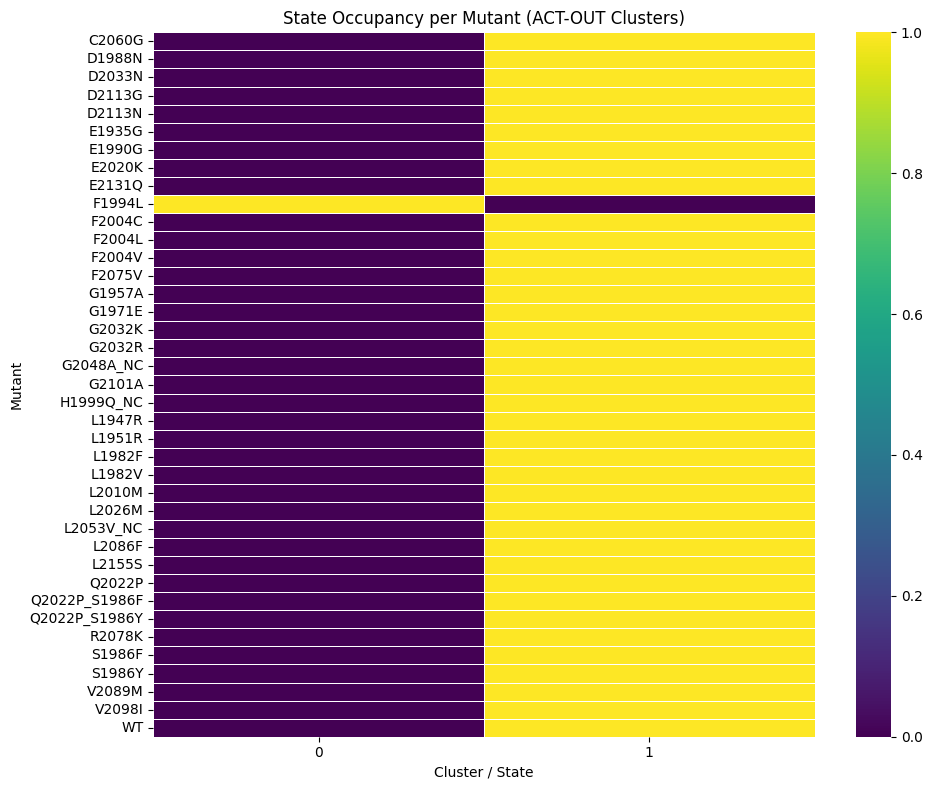

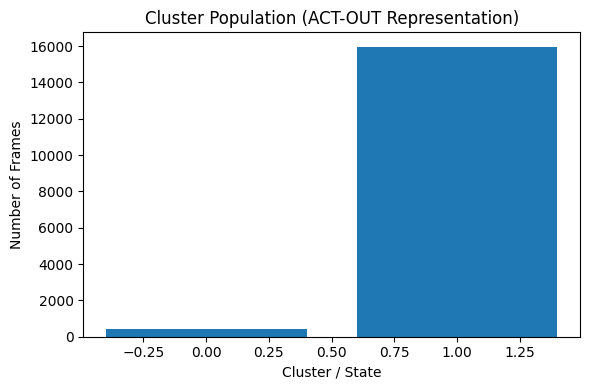

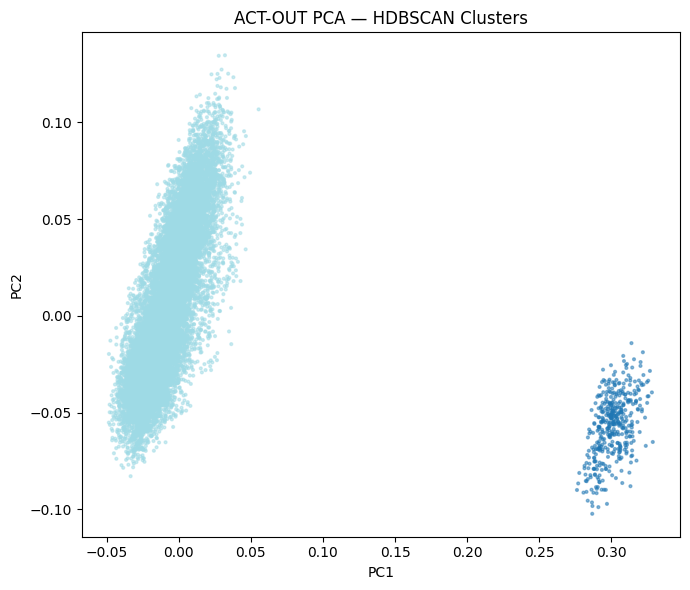

In [20]:
# Visualize mutant-by-state occupancy for the ACT-OUT representation
plot_occupancy_heatmap(
    frac_actout_hdb,
    title="State Occupancy per Mutant (ACT-OUT Clusters)",
    outpath="figures/actout_occupancy_heatmap.png"
)

# Show the total number of frames assigned to each ACT-OUT cluster
plot_cluster_population(
    labels_actout_hdb,
    title="Cluster Population (ACT-OUT Representation)",
    outpath="figures/actout_cluster_population.png"
)

# Plot the first two ACT-OUT principal components colored by HDBSCAN cluster
plot_pca_clusters(
    scores_flat_actout[:, 0],
    scores_flat_actout[:, 1],
    labels_actout_hdb,
    title="ACT-OUT PCA — HDBSCAN Clusters",
    outpath="figures/actout_pca_clusters.png"
)

## **Results: Feature Set 1 – Core Coordinates (ACT-OUT)**

PCA applied to backbone coordinates excluding the activation loop captured the dominant structural variation of the kinase core. However, clustering in this representation was dominated by one broad conformational basin.

The occupancy heatmap shows that most mutants populate the same dominant state, indicating that the global kinase scaffold remains largely conserved across the mutant set. The cluster population plot supports this interpretation by showing that one state contains the majority of frames.

Overall, the ACT-OUT representation suggests that mutation-dependent structural differences are limited at the level of global core geometry, and that the kinase scaffold is comparatively stable across mutants.

This suggests that mutation-dependent differences are expressed primarily through domain orientation rather than large-scale rearrangements of the kinase core.

# **ORIENTATION FEATURES (NTL vs CTL) + PCA**

The second feature representation focuses on **relative domain orientation between the N-terminal lobe (NTL) and the C-terminal lobe (CTL)** of the kinase domain.

Rather than using global backbone coordinates, this representation captures how the two major kinase lobes move relative to each other. Such motions are often functionally important because kinase activation and inhibitor binding are closely associated with changes in inter-lobe orientation.

Orientation descriptors are constructed from vectors and geometric relationships between the NTL and CTL regions. These features provide a compact representation of domain-level motions that may not be visible in global coordinate analyses.

Principal Component Analysis (PCA) is then applied to these orientation features to identify the dominant modes of inter-lobe motion before clustering is performed.

NTL CA atoms: 97
CTL CA atoms: 169
[TIMER] C1: orientation features: 13.977 s
feats_orient: (81432, 12)
[TIMER] C1: orientation PCA: 0.002 s


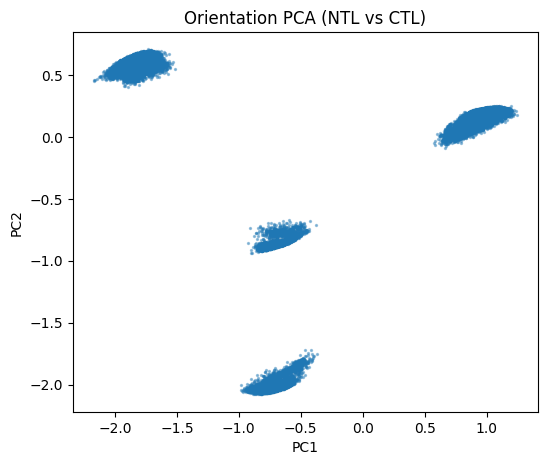

In [21]:
# ============================================================
# ORIENTATION FEATURES (NTL vs CTL) + PCA
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

mask_ntl = NTL & CA
mask_ctl = CTL & CA & (~ACT)

ntl_idx = np.where(mask_ntl)[0]
ctl_idx = np.where(mask_ctl)[0]

print("NTL CA atoms:", len(ntl_idx))
print("CTL CA atoms:", len(ctl_idx))

def principal_axis(coords):
    coords = coords - coords.mean(axis=0, keepdims=True)
    _, _, Vt = np.linalg.svd(coords, full_matrices=False)
    v = Vt[0]
    return v / (np.linalg.norm(v) + 1e-12)

def angle(u, v):
    c = np.clip(np.dot(u, v), -1.0, 1.0)
    return np.arccos(c)

nmut = len(traj_aligned)

feats_orient = np.zeros((nmut * nframes_sub, 12), dtype=np.float32)
obs = 0

with tim("C1: orientation features"):
    for ti in range(nmut):
        xyz = traj_aligned[ti]   # (nframes_sub, natoms, 3)
        ntl = xyz[:, ntl_idx, :]
        ctl = xyz[:, ctl_idx, :]

        ntl_com = ntl.mean(axis=1)
        ctl_com = ctl.mean(axis=1)

        v = ntl_com - ctl_com
        vhat = v / (np.linalg.norm(v, axis=1, keepdims=True) + 1e-12)

        for fj in range(nframes_sub):
            a_ntl = principal_axis(ntl[fj] - ntl_com[fj])
            a_ctl = principal_axis(ctl[fj] - ctl_com[fj])

            feats_orient[obs, 0:3] = vhat[fj]
            feats_orient[obs, 3:6] = a_ctl
            feats_orient[obs, 6:9] = a_ntl
            feats_orient[obs, 9]   = angle(vhat[fj], a_ctl)
            feats_orient[obs, 10]  = angle(vhat[fj], a_ntl)
            feats_orient[obs, 11]  = angle(a_ctl, a_ntl)
            obs += 1

print("feats_orient:", feats_orient.shape)

# PCA
Dc = feats_orient - feats_orient.mean(axis=0, keepdims=True)

with tim("C1: orientation PCA"):
    C = (Dc.T @ Dc) / len(Dc)
    evals, evecs = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals, evecs = evals[order], evecs[:, order]

yscores = Dc @ evecs[:, :3]
scores_orient = yscores.reshape(nmut, nframes_sub, 3)

plt.figure(figsize=(6,5))
plt.scatter(yscores[:,0], yscores[:,1], s=2, alpha=0.4)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Orientation PCA (NTL vs CTL)")
plt.show()

# **ORIENTATION CLUSTERING + OCCUPANCY PER MUTANT**

The orientation-based representation was clustered using **HDBSCAN** as the primary method and **DBSCAN** as a baseline comparison.

Cluster assignments were then converted into **state occupancy tables per mutant**, where occupancy represents the fraction of trajectory frames assigned to each orientation-defined conformational state. This makes it possible to compare how mutations alter the preferred distribution of lobe-orientation states across the ROS1 mutant set.

In [22]:
# ============================================================
# ORIENTATION CLUSTERING + OCCUPANCY PER MUTANT
# Primary: HDBSCAN
# Baseline: DBSCAN
# ============================================================

X_orient = np.column_stack([
    scores_orient[:, :, 0].reshape(-1),
    scores_orient[:, :, 1].reshape(-1),
])


labels_orient_hdb = run_hdbscan(X_orient, n_pcs=2, min_cluster_size=150)
labels_orient_db = run_dbscan(X_orient, n_pcs=2, eps=0.3, min_samples=100)

counts_orient_hdb, frac_orient_hdb = occupancy_from_traj_labels(F, nframes_sub, labels_orient_hdb)
counts_orient_db, frac_orient_db = occupancy_from_traj_labels(F, nframes_sub, labels_orient_db)

print("ORIENTATION HDBSCAN clusters:", len(set(labels_orient_hdb)) - (1 if -1 in labels_orient_hdb else 0))
print("ORIENTATION HDBSCAN noise fraction:", float(np.mean(labels_orient_hdb == -1)))

print("ORIENTATION DBSCAN clusters:", len(set(labels_orient_db)) - (1 if -1 in labels_orient_db else 0))
print("ORIENTATION DBSCAN noise fraction:", float(np.mean(labels_orient_db == -1)))

print("Orientation occupancy (HDBSCAN primary):")
display(frac_orient_hdb)

print("Orientation occupancy (DBSCAN baseline):")
display(frac_orient_db)

ORIENTATION HDBSCAN clusters: 4
ORIENTATION HDBSCAN noise fraction: 0.0
ORIENTATION DBSCAN clusters: 4
ORIENTATION DBSCAN noise fraction: 0.0
Orientation occupancy (HDBSCAN primary):


state,0,1,2,3
mutant,,,,
C2060G,0.117816,0.875479,0.006705,0.000000
D1988N,0.130268,0.808429,0.052203,0.009100
D2033N,0.138410,0.818487,0.037835,0.005268
D2113G,0.128352,0.854406,0.013889,0.003352
D2113N,0.075670,0.782567,0.140805,0.000958
E1935G,0.147031,0.839559,0.011494,0.001916
E1990G,0.459770,0.302203,0.088123,0.149904
E2020K,0.071360,0.152778,0.689176,0.086686
E2131Q,0.345307,0.592433,0.026341,0.035920


Orientation occupancy (DBSCAN baseline):


state,0,1,2,3
mutant,,,,
C2060G,0.117816,0.875479,0.006705,0.000000
D1988N,0.130268,0.808429,0.052203,0.009100
D2033N,0.138410,0.818487,0.037835,0.005268
D2113G,0.128352,0.854406,0.013889,0.003352
D2113N,0.075670,0.782567,0.140805,0.000958
E1935G,0.147031,0.839559,0.011494,0.001916
E1990G,0.459770,0.302203,0.088123,0.149904
E2020K,0.071360,0.152778,0.689176,0.086686
E2131Q,0.345307,0.592433,0.026341,0.035920


## **Orientation state occupancy and cluster distribution**

The orientation-based feature set was further summarized using three complementary plots.

The **state occupancy heatmap** shows the fraction of frames from each mutant assigned to each orientation-defined conformational state. This directly highlights mutation-dependent differences in structural preference.

The **cluster population plot** summarizes the global distribution of frames across the identified states.

Finally, the **PCA cluster plot** visualizes the first two principal components with HDBSCAN cluster labels, showing how the conformational states are separated in reduced-dimensional space.

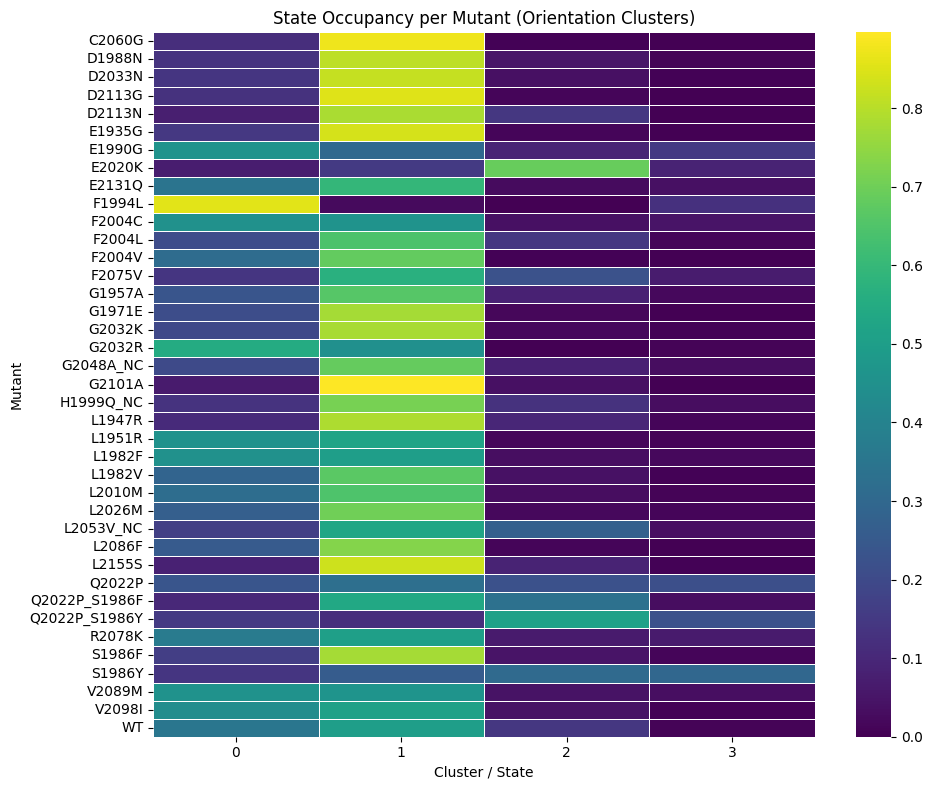

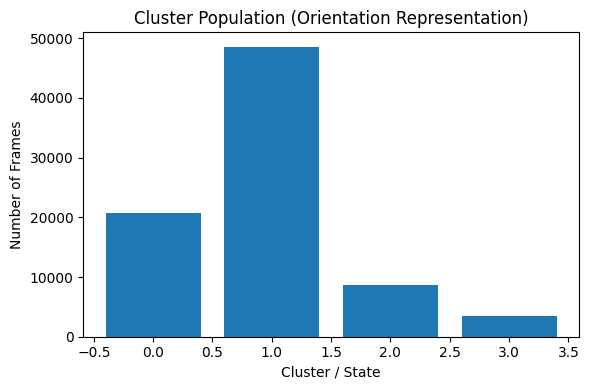

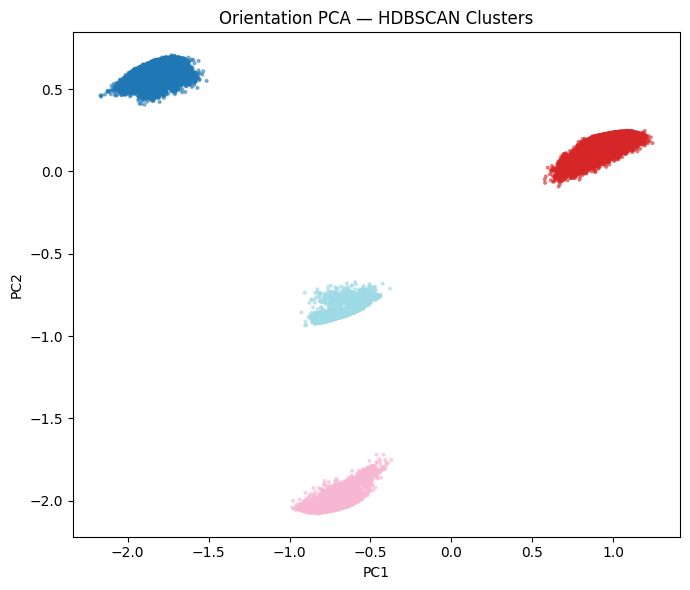

In [23]:
# Visualize mutant-by-state occupancy for the orientation representation
plot_occupancy_heatmap(
    frac_orient_hdb,
    title="State Occupancy per Mutant (Orientation Clusters)",
    outpath="figures/orientation_occupancy_heatmap.png"
)

# Show the total number of frames assigned to each orientation cluster
plot_cluster_population(
    labels_orient_hdb,
    title="Cluster Population (Orientation Representation)",
    outpath="figures/orientation_cluster_population.png"
)

# Plot the first two orientation principal components colored by HDBSCAN cluster
plot_pca_clusters(
    X_orient[:, 0],
    X_orient[:, 1],
    labels_orient_hdb,
    title="Orientation PCA — HDBSCAN Clusters",
    outpath="figures/orientation_pca_clusters.png"
)



## **Results: Feature Set 2 – Orientation Representation**

In contrast to the ACT-OUT representation, the orientation-based feature set resolved multiple conformational states. Clustering identified multiple populated states corresponding to different relative orientations of the N-terminal and C-terminal kinase lobes.

The occupancy heatmap shows that different mutants distribute their frames differently across these states, indicating mutation-dependent conformational preferences. The cluster population plot further shows that the conformational ensemble is partitioned across several populated basins rather than one dominant state.

Together, these results suggest that relative lobe orientation captures more informative dynamical variation than global core coordinates and provides the strongest unsupervised description of mutation-dependent conformational differences in ROS1.

## **Conclusion**

This project applied unsupervised learning to molecular dynamics simulations of ROS1 kinase mutants in order to identify latent conformational states and compare mutation-dependent structural preferences.

Two feature representations were examined. The ACT-OUT core-coordinate representation was dominated by a common conformational basin, suggesting that the global kinase scaffold remains relatively stable across mutants. In contrast, the orientation-based representation identified multiple conformational states and revealed clear differences in state occupancy between mutants.

These findings suggest that relative lobe orientation provides a more informative description of mutation-dependent conformational variability than global backbone coordinates. Overall, the analysis demonstrates how unsupervised learning can uncover meaningful structural states in molecular simulation data and support mechanistic interpretation of cancer-associated mutations.

## **References**

1. Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996).  
   A density-based algorithm for discovering clusters in large spatial databases with noise.  
   *KDD Conference Proceedings.*

2. McInnes, L., Healy, J., & Astels, S. (2017).  
   hdbscan: Hierarchical density based clustering.  
   *Journal of Open Source Software.*

3. Hollingsworth, S. A., & Dror, R. O. (2018).  
   Molecular dynamics simulation for all.  
   *Neuron.*

4. Shukla, D., Hernández, C. X., Weber, J. K., & Pande, V. S. (2015).  
   Markov state models provide insights into protein structure and dynamics.  
   *Accounts of Chemical Research.*

5. Van Der Spoel, D. et al. (2005).  
   GROMACS: Fast, flexible, and free molecular dynamics.  
   *Journal of Computational Chemistry.*

6. Tsjerk Wassenaar.  
   gromit: Molecular dynamics analysis tools.